# 🛒📊 Walmart Weekly Sales Forecasting with Machine Learning

## 🎯 Business Problem

Retail companies like **Walmart** must predict product demand across thousands of stores.

Accurate forecasting helps businesses:

- 📦 Optimize **inventory management**
- 👥 Plan **staffing and logistics**
- 💰 Improve **revenue forecasting**
- 📉 Reduce **stockouts and overstocking**
- 🎯 Evaluate **promotion effectiveness**

In this project, we build **Machine Learning models** to forecast **weekly sales across Walmart stores and departments**.

## 📚 Import Libraries

We import libraries that support different stages of the data science workflow.

- **Pandas & NumPy** → data manipulation and numerical operations  
- **Matplotlib & Seaborn** → data visualization  
- **Scikit-learn** → machine learning models  
- **Evaluation metrics** → measure model performance  

These tools form the foundation of many **real-world machine learning pipelines**.

In [28]:
# data handling
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 📥 Load the Dataset

The dataset consists of three main tables:

| Dataset | Description |
|------|------|
| `train` | Historical weekly sales |
| `features` | Economic indicators and promotion markdowns |
| `stores` | Store metadata such as store type |

From a **business perspective**, these datasets help explain **why sales fluctuate across stores and time**.

For example:

- Promotional markdowns may increase sales
- Holidays often cause spikes in demand
- Store types may influence purchasing behavior

In [29]:
train = pd.read_csv(r"C:\Users\DELL LATITUDE\Downloads\walmart-recruiting-store-sales-forecasting\train.csv\train.csv")
features = pd.read_csv(r"C:\Users\DELL LATITUDE\Downloads\walmart-recruiting-store-sales-forecasting\features.csv\features.csv")
stores = pd.read_csv(r"C:\Users\DELL LATITUDE\Downloads\walmart-recruiting-store-sales-forecasting\stores.csv")

train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


## 🔗 Merge the Datasets

To perform meaningful analysis, we combine the datasets into **one unified dataset**.

This ensures each record includes:

- Store information  
- Sales history  
- Economic indicators  
- Promotional campaign data  

This is a common step in **real-world business analytics pipelines**, where data comes from multiple systems.

In [30]:
df = pd.merge(train,features, on = ["Store","Date","IsHoliday"])
df= pd.merge(df,stores,on = "Store")

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


## 🔍 Exploratory Data Analysis (EDA)

Before building machine learning models, we explore the dataset to understand:

- Data types
- Missing values
- Summary statistics

This step helps identify **data quality issues** and ensures the dataset is ready for modeling.

EDA also helps uncover **early business insights**, such as unusual sales values or missing promotional data.

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [32]:
df.describe()

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
std,12.785297,30.492054,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000


## 🧹 Handling Missing Values

The dataset contains missing values in the **promotion markdown variables**.

From a **business perspective**, missing markdown values likely indicate **no promotional campaign occurred**.

Instead of removing these records, we replace missing values with **0**, which represents **no markdown applied**.

This preserves valuable sales data while maintaining realistic feature values.

In [33]:
markdown_cols = ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]

df[markdown_cols] = df[markdown_cols].fillna(0)

In [34]:
df["Date"] = pd.to_datetime(df["Date"])

## ⚙️ Feature Engineering

Feature engineering helps improve model performance by creating **more informative variables**.

From the `Date` column, we extract:

- **Year**
- **Month**
- **Week**
- **Day**

These variables allow the model to learn **seasonal patterns in sales**.

Retail sales are strongly influenced by **seasonality**, including:

- Monthly shopping patterns
- Weekly customer traffic
- Holiday spending trends

In [35]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week
df["Day"] = df["Date"].dt.day

## 🔢 Encoding Categorical Variables

Machine learning models require **numerical inputs**.

The `Type` column represents store categories and is therefore **categorical**.

We convert this column into numerical variables using **One-Hot Encoding**, which creates binary indicators for each store type.

This allows models to capture **differences in sales patterns between store formats**.

In [36]:
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

## 📈 Sales Trend Visualization

To understand overall demand patterns, we visualize **total Walmart sales over time**.

This visualization can reveal:

- 📈 Long-term growth trends  
- 🎄 Holiday sales spikes  
- 📉 Seasonal fluctuations  

Understanding these trends is essential for **demand forecasting and business planning**.

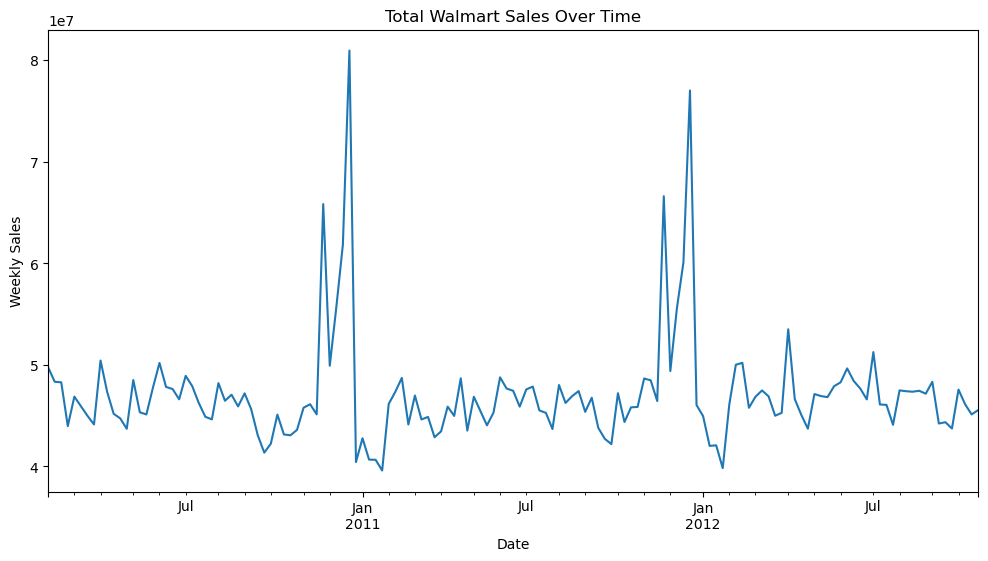

In [37]:
plt.figure(figsize=(12,6))

df.groupby("Date")["Weekly_Sales"].sum().plot()

plt.title("Total Walmart Sales Over Time")
plt.ylabel("Weekly Sales")
plt.xlabel("Date")

plt.show()

## ⏳ Lag Features (Previous Sales)

Lag features represent **sales from previous weeks**.

For example:

- `Lag_1` represents sales from the **previous week**
- `Lag_2` represents sales from **two weeks ago**

This allows the model to learn that **future sales often depend on past sales performance**.

Lag features are widely used in **time-series forecasting problems**.

In [ ]:
df["Lag_1"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(1)
df["Lag_2"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(2)

In [ ]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Size,Year,Month,Week,Day,Type_B,Type_C,Lag_1,Lag_2
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,8.106,151315,2010,2,5,5,False,False,NaN,NaN
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,8.106,151315,2010,2,6,12,False,False,24924.50,NaN
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,8.106,151315,2010,2,7,19,False,False,46039.49,24924.50
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,8.106,151315,2010,2,8,26,False,False,41595.55,46039.49
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,8.106,151315,2010,3,9,5,False,False,19403.54,41595.55


## 📉 Rolling Average Features

Rolling averages capture **short-term trends in sales performance**.

Examples:

- **4-week rolling mean** → average sales over the past month  
- **8-week rolling mean** → longer-term demand trend  

These features help smooth fluctuations and make it easier for models to detect **consistent patterns in sales behavior**.

In [ ]:
df["Rolling_Mean_4"] = df.groupby(["Store","Dept"])["Weekly_Sales"].transform(lambda x: x.shift(1).rolling(4).mean())

df["Rolling_Mean_8"] = df.groupby(["Store","Dept"])["Weekly_Sales"].transform(lambda x: x.shift(1).rolling(8).mean())

## 🧽 Removing Missing Values

Lag and rolling calculations introduce missing values at the beginning of each time series.

These rows cannot be used for training and are therefore removed.

This ensures the dataset contains **complete feature values for machine learning models**.

In [ ]:
df = df.dropna()

## 🎯 Preparing Features and Target

We separate the dataset into:

**Features (X)**  
These include all predictor variables such as store information, promotional markdowns, and engineered time features.

**Target Variable (y)**  
This is the variable we want to predict: **Weekly Sales**.

In [ ]:
X = df.drop(["Weekly_Sales","Date"], axis=1)
y = df["Weekly_Sales"]

## 🧪 Train-Test Split (Time-Based)

Unlike many machine learning problems, time-series forecasting requires **chronological splitting**.

Instead of randomly splitting the dataset, we:

- Train models using **earlier data**
- Test models on **future data**

This mimics real-world forecasting where businesses must predict **future sales using historical information**.

In [ ]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

## 📉 Linear Regression Model

Linear Regression serves as a **baseline model**.

It assumes a linear relationship between predictors and sales.

Although simple, baseline models provide an important **performance benchmark** for more advanced algorithms.

In [ ]:

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## 🌲 Random Forest Model

Random Forest is an **ensemble machine learning model** that builds multiple decision trees.

Advantages include:

- Capturing **nonlinear relationships**
- Handling **large feature sets**
- Reducing overfitting through ensemble learning

Random Forest models are widely used in **retail analytics and demand forecasting**.

In [ ]:

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## 📏 Model Evaluation

To evaluate model performance, we use two metrics:

**Mean Absolute Error (MAE)**  
Average magnitude of prediction errors.

**Root Mean Squared Error (RMSE)**  
Penalizes larger errors more heavily.

Lower values indicate **better predictive performance**.

These metrics help determine which model provides **the most accurate sales forecasts**.

In [ ]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Linear Regression RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf)

Linear Regression RMSE: 5401.07939798838
Random Forest RMSE: 4258.183539688017


## 📊 Actual vs Predicted Sales

We visualize the model’s predictions against actual sales values.

This allows us to visually assess:

- Prediction accuracy
- Trend alignment
- Potential forecasting errors

Visualization is an important step when communicating **model performance to business stakeholders**.

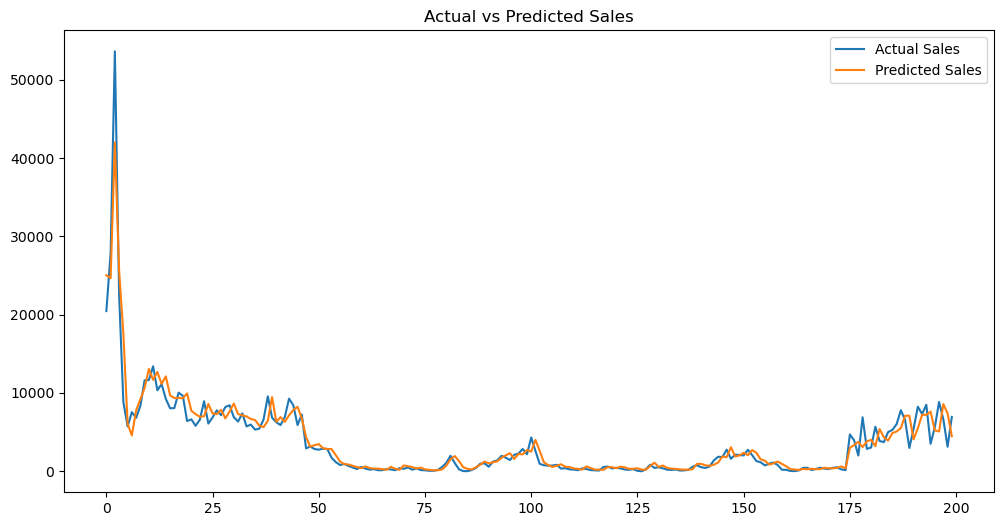

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label="Actual Sales")
plt.plot(y_pred_rf[:200], label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.legend()

plt.show()

## 🚀 XGBoost Model

XGBoost is a powerful **gradient boosting algorithm** widely used in production machine learning systems.

Key advantages include:

- High predictive accuracy  
- Ability to capture complex relationships  
- Efficient training on large datasets  

XGBoost is commonly used in **Kaggle competitions and real-world forecasting systems**.

In [ ]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 372.9 kB/s eta 0:04:32
   ---------------------------------------- 0.5/101.7 MB 372.9 kB/s eta 0:04:32
   ---------------------------------------- 0.5/101.7 MB 372.9 kB/s eta 0:04:32
   ---------------------------------------- 0.8/101.7 MB 399.3 kB/s eta 0:04:13
   --------------------------------

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test)

In [ ]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 3690.625423016706


## 🏆 Model Comparison

We compare the performance of three models:

- Linear Regression
- Random Forest
- XGBoost

This comparison helps determine which model provides the **most reliable sales forecasts**.

Selecting the best model is critical for **business decision-making and operational planning**.

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb],
    "MAE": [mae_lr, mae_rf, mae_xgb]
})

comparison

,Model,RMSE,MAE
0,Linear Regression,5401.079398,1588.724727
1,Random Forest,4258.183540,1180.477245
2,XGBoost,3690.625423,1188.338388


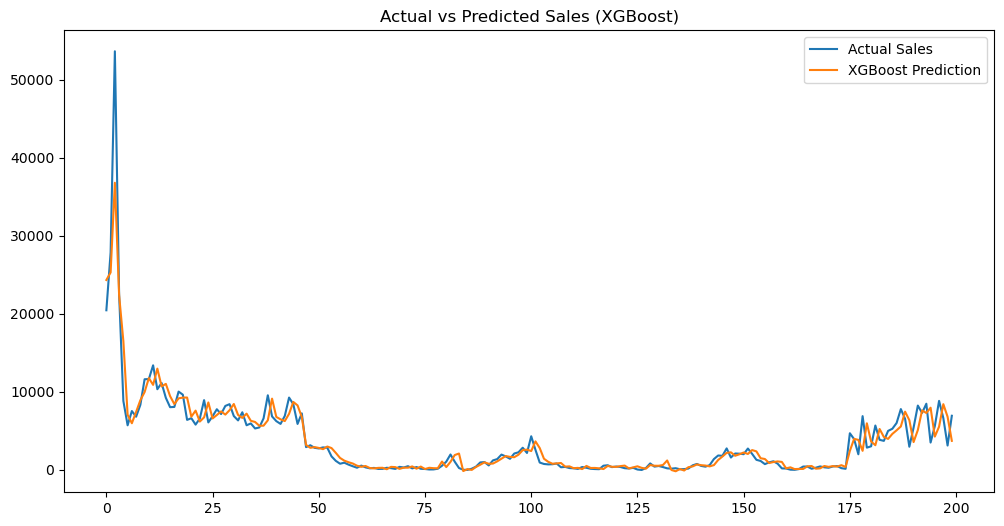

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label="Actual Sales")
plt.plot(y_pred_xgb[:200], label="XGBoost Prediction")

plt.title("Actual vs Predicted Sales (XGBoost)")
plt.legend()

plt.show()

# 📊 Key Business Insights from the Walmart Sales Forecasting Analysis

## 1️⃣ Sales Show Strong Time-Based Patterns

The sales trend over time shows that **weekly sales fluctuate significantly depending on the time of year and specific weeks**.

### 📌 Business Meaning

Retail demand is **not constant**. It is affected by:

- Seasonal shopping cycles  
- Holidays  
- Consumer purchasing behavior  

### 💡 Business Action

Walmart can:

- Increase inventory before **high-demand weeks**
- Reduce inventory during **low-demand periods**
- Optimize **warehouse and logistics planning**

## 🎄 2️⃣ Holidays Significantly Influence Sales

The dataset includes an **IsHoliday** feature, and retail data typically shows **large spikes in demand during holidays**.

### 📌 Business Meaning

Sales often surge during events such as:

- Christmas
- Thanksgiving
- Back-to-school seasons

### 💡 Business Action

Retailers should:

- Increase staffing during holidays  
- Prepare higher stock levels  
- Run targeted promotional campaigns  

This helps prevent **lost revenue caused by stock shortages**.

## 🏪 3️⃣ Store Characteristics Influence Sales

The dataset includes **store types**, which were converted into numerical variables.

Different store formats typically produce **different sales patterns**.

### 📌 Business Meaning

Some store types may:

- Attract more customers  
- Sell higher product volumes  
- Respond differently to promotions  

### 💡 Business Action

Retailers can:

- Allocate inventory differently by store type  
- Customize promotions for different store formats  
- Improve **store-specific sales forecasting**

## 💸 4️⃣ Promotions (Markdowns) Affect Sales Performance

The dataset includes **MarkDown1 – MarkDown5**, which represent promotional discounts.

Promotions often lead to **temporary increases in demand**.

### 📌 Business Meaning

Price reductions and promotional campaigns significantly influence purchasing behavior.

### 💡 Business Action

Businesses can:

- Schedule promotions strategically  
- Forecast demand increases during markdown periods  
- Optimize marketing campaigns

## 🔁 5️⃣ Past Sales Strongly Predict Future Sales

Lag features show that **previous weeks' sales help predict future sales**.

### 📌 Business Meaning

Retail demand often follows **momentum patterns**.

Example:

If a product sells well this week, it is likely to sell well next week.

### 💡 Business Action

Retailers can:

- Implement automated **rolling demand forecasts**
- Dynamically adjust inventory levels
- Anticipate demand trends early

## 🤖 6️⃣ Advanced Machine Learning Improves Forecast Accuracy

The project compares three models:

- Linear Regression  
- Random Forest  
- XGBoost  

Tree-based models such as **Random Forest and XGBoost** typically outperform simple linear models.

### 📌 Business Meaning

Retail demand is **complex and nonlinear**, making advanced machine learning models more suitable.

### 💡 Business Action

Companies should adopt **advanced ML forecasting models** to:

- Improve demand prediction accuracy  
- Reduce forecasting errors  
- Improve supply chain planning

## 📦 7️⃣ Accurate Forecasting Reduces Supply Chain Costs

Better demand predictions allow retailers to:

- Avoid overstocking  
- Prevent stockouts  
- Optimize distribution and transportation  

### 💼 Business Impact

Accurate demand forecasting leads to:

- Lower inventory costs  
- Higher sales revenue  
- Improved customer satisfaction

# ⭐ Key Takeaway

The analysis shows that Walmart sales are strongly influenced by:

- Seasonal demand patterns  
- Promotional markdowns  
- Historical sales performance  

Machine learning models such as **Random Forest and XGBoost** can capture these complex relationships and significantly improve demand forecasting accuracy.

These insights help retailers:

- Optimize inventory planning  
- Reduce stock shortages  
- Improve supply chain efficiency  
- Make data-driven operational decisions